In [1]:
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import math
import scipy
from scipy.spatial import cKDTree
from scipy import integrate
from scipy import interpolate
from scipy.spatial import Delaunay
from scipy.spatial import Voronoi
from itertools import product
import torch
torch.manual_seed(100000)
import torch.nn as nn
import torch.optim as optim
import pysindy as ps



/homes/yinonghyn/.local/lib/python3.10/site-packages/pysindy/feature_library/base.py:40: DeprecationWarning: Library ensembling is no longer performed by feature libraries.  Use EnsemblingOptimizer to fit an ensemble model.
  warnings.warn(


In [2]:
#settings
N = 5  # Number of variables
F = 8  # Forcing
start = F * np.ones(N)  # Initial state (equilibrium)
start[0] += 0.01  # Add small perturbation to the first variable
dt = 0.01
subset_size = 200
traj_length = int(1e6)#length of trajectory
noise_level = 0.05
sample_size = int(5000)
slope = 0.1

simulation_t = int(5e3)
def L96(x, t):
    """Lorenz 96 model with constant forcing"""
    return (np.roll(x, -1) - np.roll(x, 2)) * np.roll(x, 1) - x + F 


t = np.arange(0.0, traj_length*dt, dt)



In [3]:
trajectory_clean = scipy.integrate.odeint(L96, start, t)

In [4]:
trajectory = trajectory_clean + np.random.normal(0,noise_level,((traj_length,5)))#loooooooong trajectory
trajectory = trajectory[int(1e3):]

#a random chuck of data
rand_start = np.random.randint(1, len(trajectory)-sample_size)
randpts = torch.tensor(trajectory[rand_start:rand_start+sample_size],dtype = torch.float)
Trandpts = torch.tensor(trajectory[rand_start+1:rand_start+1+sample_size],dtype = torch.float)

#normalization
M_scale = torch.max(torch.abs(randpts))
randpts /= M_scale
Trandpts /= M_scale

#Voronoi cell center
Voronoi_centers = MiniBatchKMeans(n_clusters=subset_size).fit(randpts).cluster_centers_

tree = cKDTree(Voronoi_centers)
Voronoi_centers = torch.tensor(Voronoi_centers,dtype = torch.float)

relu = nn.ReLU()

def decay(x):
    return relu(1-slope*x)
def w(xs):
    dists =  torch.cdist(xs, Voronoi_centers, p =2)
    pre_w = decay(dists)
    return  pre_w / torch.sum(pre_w, dim=1,keepdim = True)


def Ulam(points,Tpoints):
    mat = torch.zeros((subset_size, subset_size))
    #before normalization
    with torch.no_grad():
          randpts_idxs = torch.tensor(tree.query(points.detach().numpy())[1], dtype=torch.int)
    weights = w(Tpoints)
    mat.index_add_(0, randpts_idxs, weights)
    mat = (mat.T)/mat.sum(dim = 1)
    return mat
class W2Loss(torch.autograd.Function):#MAT
    @staticmethod
    def forward(ctx, U_net):
        U_net_np = U_net.detach().numpy()
        cost_cols,grad = np.zeros(subset_size),np.zeros((subset_size,subset_size))
        costM = ot.dist(np.arange(subset_size).reshape(-1, 1), np.arange(subset_size).reshape(-1, 1))
        for col in range(subset_size):
            _, log = ot.emd(U_true_np[:,col], U_net_np[:,col], costM, log=True)
            cost_cols[col],grad[col] = log['cost'],log["v"]
        loss,grad = np.sum(cost_cols),grad.T
        grad_tensor = torch.tensor(grad, dtype=U_net.dtype)
        ctx.save_for_backward(grad_tensor)
        return torch.tensor(loss, dtype=U_net.dtype)
    @staticmethod
    def backward(ctx, grad_output):
        grad_tensor, = ctx.saved_tensors  # Unpack gradient
        return grad_tensor.reshape(subset_size,subset_size)
U_true = Ulam(randpts,Trandpts)
U_true_np = U_true.detach().cpu().numpy()

/homes/yinonghyn/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1930: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


In [5]:
torch.manual_seed(100000)
net1 = nn.Sequential(
            nn.Linear(5, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 5))

optimizer1 = optim.Adam(net1.parameters(),lr = 1e-3)

N_iters = 100000

net1.train()
loss1 = []
invert_variables = [0,1,2,3,4]
net1_randpts = randpts.clone()  # safe copy, avoid modifying original tensor

V_field = net1(net1_randpts)
net1_randpts = net1_randpts+dt* V_field
U_net = Ulam(randpts,net1_randpts)

initial_L1 = W2Loss.apply(U_net)

Iteration 0, Loss(Ours): 1.4011120796203613


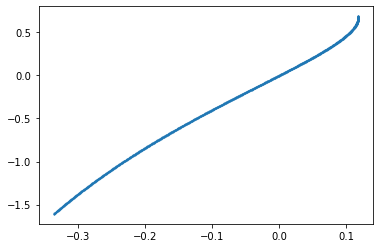

Iteration 500, Loss(Ours): 0.04836110770702362
Early stopping at iteration 500, Loss: 0.04836110770702362


In [6]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer1.zero_grad()
 
    net1_randpts = randpts

    V_field = net1(net1_randpts)
    net1_randpts = net1_randpts+dt* V_field
    U_net = Ulam(randpts,net1_randpts)
    L1 = W2Loss.apply(U_net)
    L1.backward()
    optimizer1.step()
    loss1.append(L1.item())  # Directly use .item() for scalar value

    # Logging
    with torch.no_grad():
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Ours): {L1.item()}') 
            if L1.item() < 0.05  * initial_L1:
                print(f"Early stopping at iteration {i}, Loss: {L1.item()}")
                break
    if i % 2000 == 0:
        x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
        # x2 = x1
        vals1= []
        for _ in range(int(1e3)):

            V_field = net1(x1)
            x1 = x1 + V_field*dt
                
            vals1.append(x1.detach().numpy().flatten()) 
        
        vals1= np.array(vals1)
        plt.scatter(vals1[:, 0], vals1[:, 1], s=1)
        plt.show()

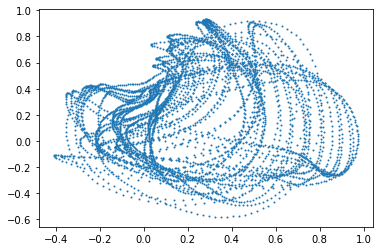

In [7]:
x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
vals1 = [x1.detach().numpy().flatten()]
for _ in range(simulation_t-1):


    V_field = net1(x1)
    x1 = x1 + V_field*dt
    vals1.append(x1.detach().numpy().flatten())
vals1 = np.array(vals1)
plt.scatter(vals1[:, 0], vals1[:, 1], s=1)
plt.show()

In [8]:
torch.manual_seed(100000)
net2 = nn.Sequential(
            nn.Linear(5, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 5))


optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
net2.train()


loss2 = []
net2_randpts = randpts.clone()  

V_field2 = net2(net2_randpts)
net2_randpts = net2_randpts+dt* V_field2
U_net = Ulam(randpts,net2_randpts)
initial_L2 = torch.mean((net2_randpts - Trandpts) ** 2)

Iteration 0, Loss(Ours): 0.00041855365270748734


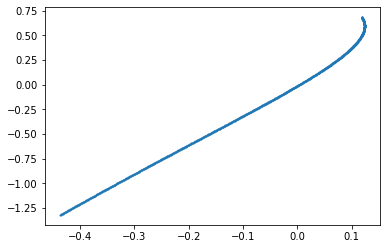

Iteration 500, Loss(Ours): 4.936322147841565e-05
Iteration 1000, Loss(Ours): 4.8536960093770176e-05
Iteration 1500, Loss(Ours): 4.820263711735606e-05
Iteration 2000, Loss(Ours): 4.786756471730769e-05
Iteration 2500, Loss(Ours): 4.751716187456623e-05
Iteration 3000, Loss(Ours): 4.704007733380422e-05
Iteration 3500, Loss(Ours): 4.66638412035536e-05
Iteration 4000, Loss(Ours): 4.6171207941370085e-05
Iteration 4500, Loss(Ours): 4.5743225200567394e-05
Iteration 5000, Loss(Ours): 4.5333905291045085e-05
Iteration 5500, Loss(Ours): 4.493703818297945e-05
Iteration 6000, Loss(Ours): 4.453219298738986e-05
Iteration 6500, Loss(Ours): 4.414248905959539e-05
Iteration 7000, Loss(Ours): 4.376671859063208e-05
Iteration 7500, Loss(Ours): 4.3398224079282954e-05
Iteration 8000, Loss(Ours): 4.30371037509758e-05
Iteration 8500, Loss(Ours): 4.267758413334377e-05
Iteration 9000, Loss(Ours): 4.231369894114323e-05
Iteration 9500, Loss(Ours): 4.1947441786760464e-05
Iteration 10000, Loss(Ours): 4.158209776505828e

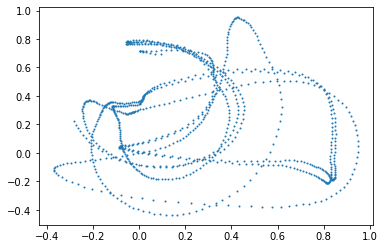

Iteration 10500, Loss(Ours): 4.121760866837576e-05
Iteration 11000, Loss(Ours): 4.085047112312168e-05
Iteration 11500, Loss(Ours): 4.048315895488486e-05
Iteration 12000, Loss(Ours): 4.011663986602798e-05
Iteration 12500, Loss(Ours): 3.974696301156655e-05
Iteration 13000, Loss(Ours): 3.954103885916993e-05
Iteration 13500, Loss(Ours): 3.9023871067911386e-05
Iteration 14000, Loss(Ours): 3.865955659421161e-05
Iteration 14500, Loss(Ours): 3.833729715552181e-05
Iteration 15000, Loss(Ours): 3.794334770645946e-05
Iteration 15500, Loss(Ours): 3.756654405151494e-05
Iteration 16000, Loss(Ours): 3.720769745996222e-05
Iteration 16500, Loss(Ours): 3.726090653799474e-05
Iteration 17000, Loss(Ours): 3.649902282631956e-05
Iteration 17500, Loss(Ours): 3.6199136957293376e-05
Iteration 18000, Loss(Ours): 3.581473356462084e-05
Iteration 18500, Loss(Ours): 3.548295353539288e-05
Iteration 19000, Loss(Ours): 3.515065327519551e-05
Iteration 19500, Loss(Ours): 3.482287866063416e-05
Iteration 20000, Loss(Ours): 

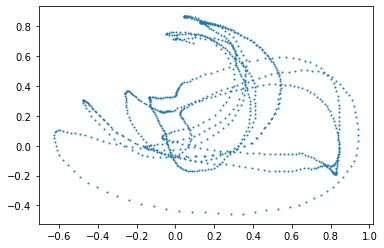

Iteration 20500, Loss(Ours): 3.4212946047773585e-05
Iteration 21000, Loss(Ours): 3.385866148164496e-05
Iteration 21500, Loss(Ours): 3.3544827601872385e-05
Iteration 22000, Loss(Ours): 3.3219443139387295e-05
Iteration 22500, Loss(Ours): 3.290739914518781e-05
Iteration 23000, Loss(Ours): 3.263639518991113e-05
Iteration 23500, Loss(Ours): 3.243424362153746e-05
Iteration 24000, Loss(Ours): 3.1967254471965134e-05
Iteration 24500, Loss(Ours): 3.16790901706554e-05
Iteration 25000, Loss(Ours): 3.1365634640678763e-05
Iteration 25500, Loss(Ours): 3.1080253393156454e-05
Iteration 26000, Loss(Ours): 3.085874777752906e-05
Iteration 26500, Loss(Ours): 3.0520786822307855e-05
Iteration 27000, Loss(Ours): 3.0241739295888692e-05
Iteration 27500, Loss(Ours): 3.0094332032604143e-05
Iteration 28000, Loss(Ours): 2.9800456104567274e-05
Iteration 28500, Loss(Ours): 2.969028901134152e-05
Iteration 29000, Loss(Ours): 2.9245411496958695e-05
Iteration 29500, Loss(Ours): 2.9033100872766227e-05
Iteration 30000, Los

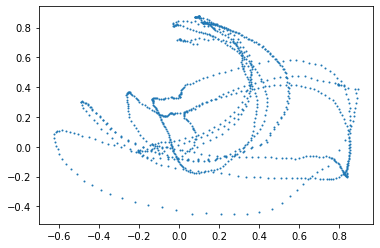

Iteration 30500, Loss(Ours): 2.8662083423114382e-05
Iteration 31000, Loss(Ours): 2.8366355763864703e-05
Iteration 31500, Loss(Ours): 2.8154794563306496e-05
Iteration 32000, Loss(Ours): 2.7956755729974248e-05
Iteration 32500, Loss(Ours): 2.775384928099811e-05
Iteration 33000, Loss(Ours): 2.7563179173739627e-05
Iteration 33500, Loss(Ours): 2.7372818294679746e-05
Iteration 34000, Loss(Ours): 2.7230971682001837e-05
Iteration 34500, Loss(Ours): 2.7006297386833467e-05
Iteration 35000, Loss(Ours): 2.6832347430172376e-05
Iteration 35500, Loss(Ours): 2.670222966116853e-05
Iteration 36000, Loss(Ours): 2.6493333280086517e-05
Iteration 36500, Loss(Ours): 2.6495368729229085e-05
Iteration 37000, Loss(Ours): 2.6188343326793984e-05
Iteration 37500, Loss(Ours): 2.605973531899508e-05
Iteration 38000, Loss(Ours): 2.5869958335533738e-05
Iteration 38500, Loss(Ours): 2.5762916266103275e-05
Iteration 39000, Loss(Ours): 2.555971877882257e-05
Iteration 39500, Loss(Ours): 2.5407694920431823e-05
Iteration 40000,

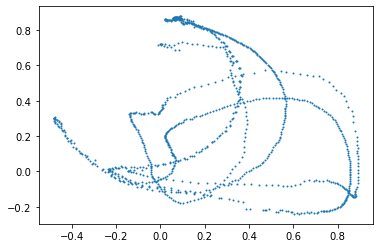

Iteration 40500, Loss(Ours): 2.512783248675987e-05
Iteration 41000, Loss(Ours): 2.5019931854330935e-05
Iteration 41500, Loss(Ours): 2.49062868533656e-05
Iteration 42000, Loss(Ours): 2.472565211064648e-05
Iteration 42500, Loss(Ours): 2.476298868714366e-05
Iteration 43000, Loss(Ours): 2.4497194317518733e-05
Iteration 43500, Loss(Ours): 2.43421509367181e-05
Iteration 44000, Loss(Ours): 2.4208611648646183e-05
Iteration 44500, Loss(Ours): 2.4125753043335862e-05
Iteration 45000, Loss(Ours): 2.4021812350838445e-05
Iteration 45500, Loss(Ours): 2.3840681024012156e-05
Iteration 46000, Loss(Ours): 2.377508644713089e-05
Iteration 46500, Loss(Ours): 2.3727669031359255e-05
Iteration 47000, Loss(Ours): 2.3519958631368354e-05
Iteration 47500, Loss(Ours): 2.348063026147429e-05
Iteration 48000, Loss(Ours): 2.3267126380233094e-05
Iteration 48500, Loss(Ours): 2.3291699108085595e-05
Iteration 49000, Loss(Ours): 2.3095466531231068e-05
Iteration 49500, Loss(Ours): 2.296496859344188e-05
Iteration 50000, Loss(

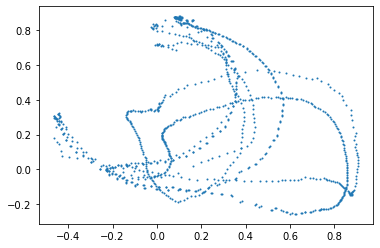

Iteration 50500, Loss(Ours): 2.2736001483281143e-05
Iteration 51000, Loss(Ours): 2.2676311346003786e-05
Iteration 51500, Loss(Ours): 2.2540039935847744e-05
Iteration 52000, Loss(Ours): 2.244194911327213e-05
Iteration 52500, Loss(Ours): 2.234167550341226e-05
Iteration 53000, Loss(Ours): 2.2283325961325318e-05
Iteration 53500, Loss(Ours): 2.215948552475311e-05
Iteration 54000, Loss(Ours): 2.2066469682613388e-05
Iteration 54500, Loss(Ours): 2.1999425371177495e-05
Iteration 55000, Loss(Ours): 2.214205960626714e-05
Iteration 55500, Loss(Ours): 2.1794392523588613e-05
Iteration 56000, Loss(Ours): 2.1702482627006248e-05
Iteration 56500, Loss(Ours): 2.1604586436296813e-05
Iteration 57000, Loss(Ours): 2.151777698600199e-05
Iteration 57500, Loss(Ours): 2.169588151446078e-05
Iteration 58000, Loss(Ours): 2.144925565517042e-05
Iteration 58500, Loss(Ours): 2.1460040443344042e-05
Iteration 59000, Loss(Ours): 2.117384246957954e-05
Iteration 59500, Loss(Ours): 2.1091129383421503e-05
Iteration 60000, Los

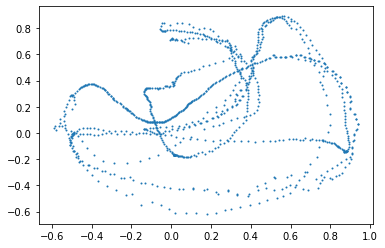

Iteration 60500, Loss(Ours): 2.092237991746515e-05
Early stopping at iteration 60500, Loss: 2.092237991746515e-05


In [9]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer2.zero_grad()

    net2_randpts = randpts

    V_field2 = net2(net2_randpts)
    net2_randpts = net2_randpts+dt*V_field2

    L2 = torch.mean((net2_randpts - Trandpts) ** 2)
    L2.backward()
    optimizer2.step()
    loss2.append(L2.item())
    # Logging
    with torch.no_grad():
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Ours): {L2.item()}')
            if L2.item() < 0.05  * initial_L2:
                print(f"Early stopping at iteration {i}, Loss: {L2.item()}")
                break
        
    # Visualization
    if i % 10000 == 0:
        x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
        vals2 = []
        for _ in range(int(1e3)):

            V_field2 = net2(x2)
            x2 = x2 + V_field2*dt
            vals2.append(x2.detach().numpy().flatten())
        vals2 = np.array(vals2)
        plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
        plt.show()

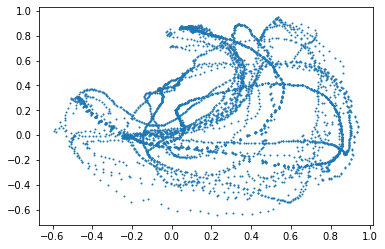

In [10]:
x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
vals2 = [x2.detach().numpy().flatten()]
for _ in range(simulation_t-1):

    V_field2 = net2(x2)
    x2 = x2 + V_field2*dt
    vals2.append(x2.detach().numpy().flatten())
vals2 = np.array(vals2)
plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
plt.show()
# plt.plot(vals2[:, 0][:100])
# plt.show()

In [11]:
#SINDy
sindy_model = ps.SINDy(feature_library=ps.PolynomialLibrary(degree= 5))
sindy_model.fit(randpts, t=dt)



/homes/yinonghyn/.local/lib/python3.10/site-packages/pysindy/feature_library/base.py:40: DeprecationWarning: Library ensembling is no longer performed by feature libraries.  Use EnsemblingOptimizer to fit an ensemble model.
  warnings.warn(


SINDy(differentiation_method=FiniteDifference(),
      feature_library=PolynomialLibrary(degree=5),
      feature_names=['x0', 'x1', 'x2', 'x3', 'x4'], optimizer=STLSQ())

In [12]:
x0 = [randpts[:, 0][0], randpts[:, 1][0],randpts[:, 2][0],randpts[:, 3][0],randpts[:, 4][0]]  # Initial values from the data
vals_sindy = [x0]  # To store the trajectory

# Manual Euler integration
x = np.array(x0)
try:
    for _ in range(simulation_t):  
        try:
            x = x + dt * sindy_model.predict(np.array(x).reshape(1, -1)).flatten()
        except ValueError as e:
            print(f"ValueError occurred: {e}")
            raise  
        vals_sindy.append(x)
except ValueError:
    print(f"Stopped simulation at outer iteration {_} due to an error.")

vals_sindy = np.array(vals_sindy)

ValueError occurred: Input X contains infinity or a value too large for dtype('float64').
Stopped simulation at outer iteration 462 due to an error.


/homes/yinonghyn/.local/lib/python3.10/site-packages/pysindy/utils/axes.py:83: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


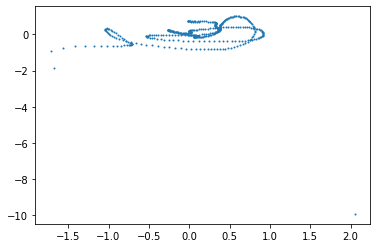

In [13]:

plt.scatter(vals_sindy[:,0][:-3],vals_sindy[:,1][:-3],s = 1)

In [14]:


GT = scipy.integrate.odeint(L96, M_scale*randpts[0], np.arange(0.0, simulation_t*dt, dt))

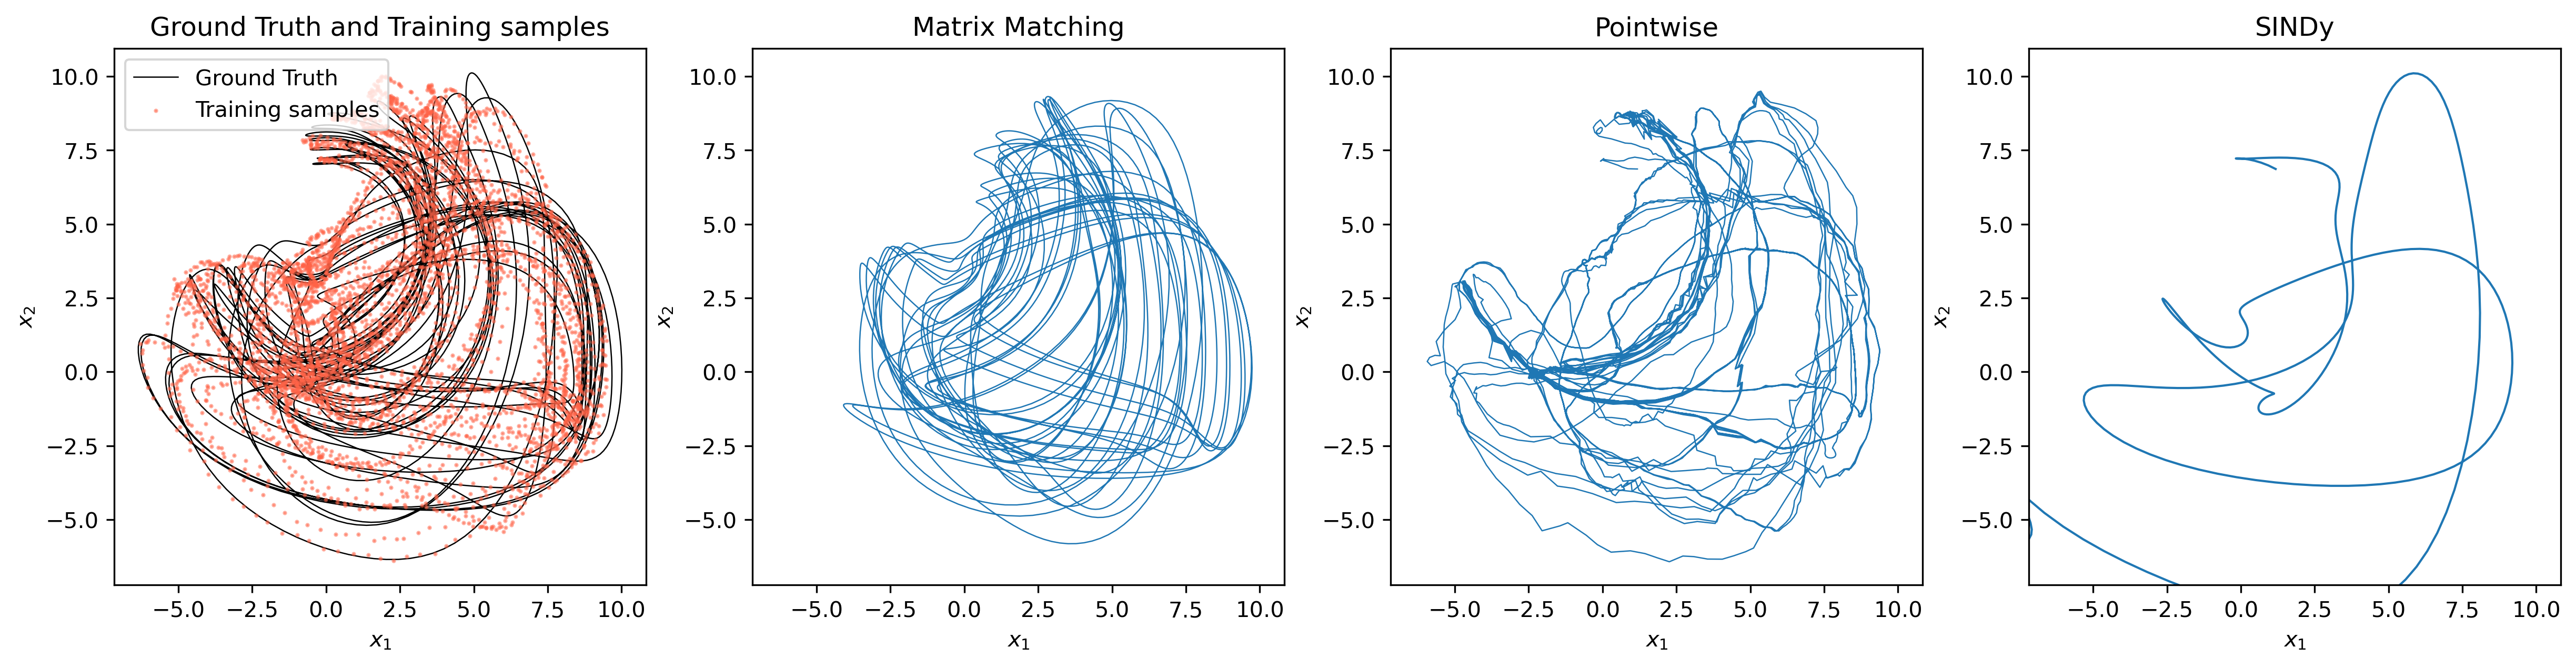

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi = 300)

axes[1].plot(M_scale * vals1[:, 0], M_scale * vals1[:, 1], linewidth=0.6)
axes[1].set_title('Matrix Matching')

axes[3].plot(M_scale * vals_sindy[:, 0][:-3], M_scale * vals_sindy[:, 1][:-3], linewidth=1)
axes[3].set_title('SINDy')

# Plot vals_ode (neural ODE results)
axes[2].plot(M_scale * vals2[:, 0], M_scale * vals2[:, 1], linewidth=0.6)
axes[2].set_title('Pointwise')

# Plot ground truth trajectory
axes[0].plot(GT[:, 0], GT[:, 1], label="Ground Truth", linewidth=0.6, zorder=1, c = "black")
axes[0].scatter(M_scale * randpts[:, 0], M_scale * randpts[:, 1], s=1, c="tomato", alpha = 0.5,
                label="Training samples", zorder=2)
axes[0].set_title('Ground Truth and Training samples')
axes[0].legend(loc='upper left')

# Set axis labels and layout
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()


for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')

plt.show()